In [ ]:
import numpy as np
import pingouin as pg



In [2]:
np.random.seed(123)
mean, cov, n = [4, 5], [(1, .6), (.6, 1)], 30
x, y = np.random.multivariate_normal(mean, cov, n).T

# T-test
pg.ttest(x, y)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-3.400706,58,two-sided,0.001222,"[-1.68, -0.43]",0.878059,26.155,0.916807


In [4]:
from pingouin import mediation_analysis, read_dataset
df = read_dataset('mediation')
mediation_analysis(data=df, x='X', m='M', y='Y', alpha=0.05,seed=42,n_boot=1000)

,path,coef,se,pval,CI[2.5%],CI[97.5%],sig
0,M ~ X,0.561015,0.094480,4.391362e-08,0.373522,0.748509,Yes
1,Y ~ M,0.654173,0.085831,1.612674e-11,0.483844,0.824501,Yes
2,Total,0.396126,0.111160,5.671128e-04,0.175533,0.616719,Yes
3,Direct,0.039604,0.109648,7.187429e-01,-0.178018,0.257226,No
4,Indirect,0.356522,0.083984,0.000000e+00,0.218835,0.538517,Yes


In [5]:
# add bootstrap samples
df = read_dataset('mediation')
print(len(df))
mediation_analysis(data=df, x='X', m='M', y='Y', alpha=0.05,seed=42,n_boot=5000)

100


,path,coef,se,pval,CI[2.5%],CI[97.5%],sig
0,M ~ X,0.561015,0.094480,4.391362e-08,0.373522,0.748509,Yes
1,Y ~ M,0.654173,0.085831,1.612674e-11,0.483844,0.824501,Yes
2,Total,0.396126,0.111160,5.671128e-04,0.175533,0.616719,Yes
3,Direct,0.039604,0.109648,7.187429e-01,-0.178018,0.257226,No
4,Indirect,0.356522,0.079928,0.000000e+00,0.219475,0.536013,Yes


In [6]:
# add covariates
mediation_analysis(data=df, x='X', m='M', y='Y',
                   covar=['Mbin', 'Ybin'], seed=42).round(3)

,path,coef,se,pval,CI[2.5%],CI[97.5%],sig
0,M ~ X,0.559,0.097,0.000,0.367,0.752,Yes
1,Y ~ M,0.666,0.086,0.000,0.495,0.837,Yes
2,Total,0.420,0.113,0.000,0.196,0.645,Yes
3,Direct,0.064,0.110,0.561,-0.155,0.284,No
4,Indirect,0.356,0.086,0.000,0.209,0.553,Yes


In [7]:
df.describe()

,X,M,Y,Mbin,Ybin,W1,W2
count,100.000000,100.000000,100.000000,100.00,100.000000,100.000000,100.000000
mean,5.990000,4.860000,5.230000,0.45,0.530000,1.435000,0.970000
std,1.743646,1.901727,2.039286,0.50,0.501614,0.872721,0.064354
min,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.800000
25%,5.000000,3.000000,4.000000,0.00,0.000000,0.737500,1.000000
50%,6.000000,5.000000,5.000000,0.00,1.000000,1.400000,1.000000
75%,7.000000,6.000000,7.000000,1.00,1.000000,2.162500,1.000000
max,10.000000,10.000000,10.000000,1.00,1.000000,3.000000,1.000000


In [8]:
from scipy.stats import zscore
df_z = df.apply(zscore)
df_z.describe()

,X,M,Y,Mbin,Ybin,W1,W2
count,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02
mean,-1.521006e-16,-1.759703e-16,-1.940115e-16,-1.776357e-17,2.220446e-18,-5.551115e-17,5.051515e-16
std,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00
min,-3.452636e+00,-2.568446e+00,-2.577543e+00,-9.045340e-01,-1.061913e+00,-1.652567e+00,-2.654954e+00
25%,-5.706360e-01,-9.829856e-01,-6.061909e-01,-9.045340e-01,-1.061913e+00,-8.032511e-01,4.685213e-01
50%,5.764000e-03,7.398817e-02,-1.133528e-01,-9.045340e-01,9.416966e-01,-4.030651e-02,4.685213e-01
75%,5.821640e-01,6.024751e-01,8.723235e-01,1.105542e+00,9.416966e-01,8.377996e-01,4.685213e-01
max,2.311364e+00,2.716423e+00,2.350838e+00,1.105542e+00,9.416966e-01,1.802277e+00,4.685213e-01


In [9]:
mediation_analysis(data=df_z, x='X', m='M', y='Y',
                   covar=['Mbin', 'Ybin'], seed=42).round(3)

,path,coef,se,pval,CI[2.5%],CI[97.5%],sig
0,M ~ X,0.513,0.089,0.000,0.337,0.689,Yes
1,Y ~ M,0.621,0.080,0.000,0.462,0.780,Yes
2,Total,0.359,0.097,0.000,0.168,0.551,Yes
3,Direct,0.055,0.094,0.561,-0.132,0.243,No
4,Indirect,0.304,0.074,0.000,0.179,0.473,Yes


4

# Setup for voxel-based mediation analysis in stroke 

In [1]:
import nibabel as nb
import pandas as pd
import glob
from pathlib import Path
from matplotlib import pyplot as plt
import time
from pingouin import mediation_analysis
import numpy as np
from scipy.stats import zscore, false_discovery_control
from statsmodels.stats.multitest import fdrcorrection, fdrcorrection_twostage


In [2]:
#WHEN USING REMOTE DATA
local_extras_dir = '../local_extras/'
out_dir = '/tmp/stechr/mediation_analysis_v2/'
#image_path = f'{local_extras_dir}/standardized_disconnectomes/' #pre-standardized
image_path = f'{local_extras_dir}/Structural-Proprioceptive-Disconnectome-Stroke-main/Disconnectomes/'
image_path = f'{local_extras_dir}/STROMAP_MNI_Disconnectomes/'
mask_fname = f'{local_extras_dir}/disconnectome_38sub_WM_mask_no_cerebellum.nii.gz'
bx_df_fname = f'{local_extras_dir}/Demographics_and_Behavioural_Data.csv'


#WHEN USING SERVER DATA
image_path = '/data/neuralabc/kaemik/MNI_StrokeDisconnect/processing/disconnectomes/'
mask_fname = '/data/neuralabc/kaemik/Mediation_StrokeDisconnect/processing/disconnectome_38sub_WM_mask_no_cerebellum.nii.gz'
bx_df_fname = '/data/neuralabc/kaemik//MNI_StrokeDisconnect/Github/Demographic_and_Behavioural_Data/Demographics_and_Behavioural_Data.csv'

In [3]:
# the disconnectomes uploaded to github are not the same subjects (?) as those used by Mika in the subsequent
# mediation analysis - XXX Why is this?
# 
# # normalized_data_list_ids = ['S01' ,'S03' ,'S04' ,'S05' ,'S07' ,'S08' ,'S09' ,'S10' ,'S11' ,'S12' ,'S13' ,'S14' ,'S16' ,'S17' ,'S18' ,'S19' ,'S20' ,'S21' ,'S22' ,'S23' ,'S24' ,'S25' ,'S26' ,'S27' ,'S28' ,'S29' ,'S30' ,'S31' ,'S32' ,'S33' ,'S34' ,'S35' ,'S36' ,'S37' ,'S38' ,'S39' ,'S41' ,'S42']
# len(normalized_data_list_ids)

In [4]:
all_images = sorted(glob.glob(f'{image_path}/*.nii.gz'))
df = pd.read_csv(bx_df_fname)
mask = nb.load(mask_fname)
mask_d = mask.get_fdata()>0 #convert to binary

print(f'{len(all_images)} images found')
print(f'{(mask.get_fdata()>0).sum()} voxels in mask')
print(f'df shape: {df.shape}')
df.head()

44 images found
672377 voxels in mask
df shape: (39, 6)


,Subject,Sex (M=0),Age (y),FM-UL Score,APM Task Score,VGR Task Score
0,S01,0,79,17.0,3.29,2.82
1,S02,0,50,4.0,5.14,NaN
2,S03,0,68,45.0,1.09,0.94
3,S04,1,49,53.0,2.04,2.48
4,S05,1,50,51.0,2.12,3.52


In [5]:
image_ids = [Path(f).stem.split('-')[1].split('_')[0] for f in all_images]

print(len(image_ids))
df_subset = df[df['Subject'].isin(image_ids)].copy() #select the ones we have images for

df_subset = df_subset.dropna(axis=0) #drop any missing data rows

#now remove any images we do not have data for
good_idx = []
for idx,image_id in enumerate(image_ids):
    if image_id in df_subset['Subject'].to_list():
        good_idx.append(idx)
print(len(good_idx))



44
38


In [6]:
# plt.plot(df_subset['APM Task Score'], df_subset['VGR Task Score'],'.')
from scipy.stats import linregress
x= df_subset['APM Task Score']
y = df_subset['VGR Task Score']
lr_res = linregress(x,y)

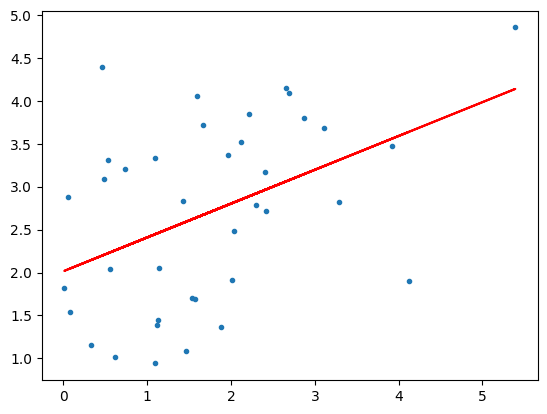

In [7]:
plt.plot(x,y,'.')
plt.plot(x, lr_res.intercept + lr_res.slope*x, 'r', label='fitted line')

# XXX can we classify individuals based on their distance from the 

In [8]:
#select the good images
image_ids = [image_ids[i] for i in good_idx]
assert(df_subset.Subject.tolist() == image_ids)
all_images = [all_images[i] for i in good_idx]


In [9]:
for idx,img_f in enumerate(all_images):
    print(idx,end=',')
    img = nb.load(img_f)
    if idx == 0:
        all_data = np.zeros((len(all_images), mask_d.sum()),dtype=np.float32)
    all_data[idx,:] = img.get_fdata()[mask_d]
print("")
print(all_data.shape)

0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,
(38, 672377)


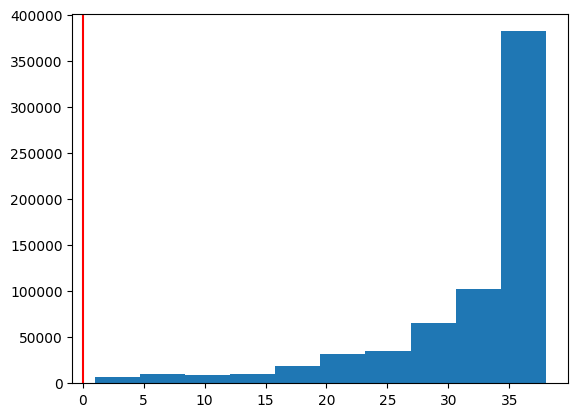

Subjects X voxels
(38, 672377)
[0.30709496 0.32253623 0.30485454 ... 0.01031613 0.00603225 0.00237897]


In [10]:
# subselect the data based on some thresholding
#check all_data for locations where there is no disconnectome

vox_pct_thresh = .0 #amount of disconnection to cut at
min_num_Ss = 0 #require this minimum number of subjects
Ss_w_vox_gt_thresh = (all_data>vox_pct_thresh).sum(axis=0)
_ = plt.hist(Ss_w_vox_gt_thresh,bins=10)
plt.axvline(min_num_Ss,color='r')
plt.show()
selected_vox_bool = Ss_w_vox_gt_thresh>=min_num_Ss


d_subset = all_data[:,selected_vox_bool]
d_subset_zscored = (d_subset - d_subset.mean(axis=0)) / d_subset.std(axis=0)

print("Subjects X voxels")
print(d_subset.shape)
print(np.mean(d_subset,axis=0))

out_d = np.zeros(mask_d.shape,dtype=np.int8)
out_d[mask_d] = selected_vox_bool.astype(np.int8)
img_out = nb.Nifti1Image(out_d,mask.affine,mask.header)
img_out.to_filename(f'{out_dir}/selected_voxels_mask_pctThresh_{str(vox_pct_thresh).replace('.','p')}_minSs_{min_num_Ss}.nii.gz')

In [11]:
# %timeit mediation_analysis(data=_df, x='vox_dconn_z', m='APM Task Score', y='VGR Task Score',covar=['Age (y)', 'Sex (M=0)'], seed=42)
# %timeit mediation_analysis(data=_df, x='vox_dconn_z', m='APM Task Score', y='VGR Task Score',covar=['Age (y)', 'Sex (M=0)'], seed=42, n_boot=5000)

In [12]:
#setup the data structures for running the analysis
M_var = 'APM Task Score' #set the mediator
# Y_var = 'VGR Task Score' #set the outcome variable
Y_var = 'FM-UL Score'
vox_idx = 0
_df = df_subset.copy()
_df['vox_dconn_z'] = d_subset_zscored[:,vox_idx]

# zscore the numeric columns
_df = _df.apply(lambda x: zscore(x) if x.name not in ['Subject'] else x)

res = mediation_analysis(data=_df, x='vox_dconn_z', m=M_var, y=Y_var,
                covar=['Age (y)', 'Sex (M=0)'], seed=42,return_dist=False)

#column and rownames, so that we know what the outputs were
column_names = res.columns
row_names = res[column_names[0]].to_list()

n_vox = d_subset_zscored.shape[1]
print(_df.describe())
_df.head()

          Sex (M=0)       Age (y)   FM-UL Score  APM Task Score  \
count  3.800000e+01  3.800000e+01  3.800000e+01    3.800000e+01   
mean   2.337312e-17  1.110223e-16  6.135443e-17   -2.921640e-17   
std    1.013423e+00  1.013423e+00  1.013423e+00    1.013423e+00   
min   -7.211103e-01 -2.348124e+00 -2.492071e+00   -1.449403e+00   
25%   -7.211103e-01 -5.551671e-01 -3.416721e-01   -7.700575e-01   
50%   -7.211103e-01 -1.593195e-01  3.886521e-01   -1.326468e-01   
75%    1.386750e+00  7.255163e-01  7.335274e-01    5.404087e-01   
max    1.386750e+00  1.936344e+00  9.972556e-01    3.062794e+00   

       VGR Task Score   vox_dconn_z  
count    3.800000e+01  3.800000e+01  
mean     1.754810e-16  3.137087e-09  
std      1.013423e+00  1.013423e+00  
min     -1.646063e+00 -8.260882e-01  
25%     -9.080877e-01 -8.260882e-01  
50%      1.194723e-01 -3.779772e-01  
75%      7.546912e-01  5.200523e-01  
max      2.015788e+00  1.863921e+00  


,Subject,Sex (M=0),Age (y),FM-UL Score,APM Task Score,VGR Task Score,vox_dconn_z
0,S01,-0.72111,1.750063,-2.492071,1.301527,0.110131,1.415573
2,S03,-0.72111,0.725516,-0.219951,-0.543609,-1.646063,-0.826088
3,S04,1.38675,-1.044155,0.429226,0.253154,-0.207479,0.071623
4,S05,1.38675,-0.951015,0.266931,0.320250,0.764033,-0.826088
5,S07,-0.72111,-0.392171,0.185784,-0.543609,0.595886,-0.826088


In [13]:
# print(res[0])
# _bstraps = res[1]
# _= plt.hist(_bstraps,bins=100)
# print(np.mean(_bstraps))
# np.percentile(_bstraps,[5,97.5])
# np.sum(_bstraps<0)/500

In [14]:
a, b = np.percentile(np.random.rand(1,100),[5,95],axis=1)
b[0]

np.float64(0.9599811090337903)

In [15]:
import numpy as np
from joblib import Parallel, delayed

#computing p-vals, referenced here: https://pmc.ncbi.nlm.nih.gov/articles/PMC9197131/
# can use a directional percentile as follows: lower_CI = np.percentile(ab_boot, 5, axis=1)
#  if >0, 95% are above this value, but not the actual p-val
# actual p-value calcs, w/ the second being more conservative: (CHECK: https://iccpp.org/wp-content/uploads/2020/08/Methodology-in-the-Social-Sciences-Andrew-F.-Hayes-Introduction-to-Mediation-Moderation-and-Conditional-Process-Analysis_-A-Regression-Based-Approach-Guilford-Publications-2018.pdf)
# a) print((_indirect_bootstrapped_betas<=0).sum(axis=1)/n_boot )
# b) p_one_sided = (np.sum(_indirect_bootstrapped_betas <= 0, axis=1) + 1) / (float(n_boot)+1)
# print(p_one_sided)

def run_single_voxel(vox_idx,M_var,Y_var,n_boot=10,return_dist=False): #set n_boot to 50 for speed (5000 for real)
    X = d_subset_zscored[:, vox_idx]

    # Construct minimal DataFrame for each voxel/worker
    _t_df = _df.copy()
    _t_df['vox_dconn_z'] = X

    res = mediation_analysis(
        data=_t_df,
        x='vox_dconn_z',
        m=M_var,
        y=Y_var,
        covar=['Age (y)', 'Sex (M=0)'],
        seed=42,
        n_boot=n_boot,
        return_dist=return_dist)

    # Output buffers (float32 faster & safer than float16)
    M_X = np.zeros(6, dtype=np.float32)
    Y_M = np.zeros(6, dtype=np.float32)
    tot = np.zeros(6, dtype=np.float32)
    direct = np.zeros(6, dtype=np.float32)
    indirect = np.zeros(6, dtype=np.float32)
    
    if return_dist:
        indirect_bootstrapped_betas = np.zeros(n_boot,dtype=np.float32)
    else:
        indirect_bootstrapped_betas = []
        lower_1sided_CI = []
        upper_1sided_CI = []
        pos_1sided_pval = []
        neg_1sided_pval = []

    if return_dist:
        indirect_bootstrapped_betas[:] = res[1]
        lower_1sided_CI, upper_1sided_CI = np.percentile(indirect_bootstrapped_betas,[5,95])
        # lower_1sided_CI = lower_1sided_CI[0]
        # upper_1sided_CI = upper_1sided_CI[0]
        print('SUCCESS')
        # <=0 for expected positive effects, >=0 for expected negative effects. Use conservative +1 here
        pos_1sided_pval = (np.sum(indirect_bootstrapped_betas <= 0) + 1) / (float(n_boot)+1)
        neg_1sided_pval = (np.sum(indirect_bootstrapped_betas >= 0) + 1) / (float(n_boot)+1)
        
        res = res[0].to_numpy()
    for name, *vals in res:
        vals[-1] = 1.0 if vals[-1] == 'Yes' else 0.0 #significance reset to 1=sig, 0=nonsig

        if name == f'{M_var} ~ X':
            M_X[:] = vals
        elif name == f'Y ~ {M_var}':
            Y_M[:] = vals
        elif name == 'Total':
            tot[:] = vals
        elif name == 'Direct':
            direct[:] = vals
        elif name == 'Indirect':
            indirect[:] = vals

    return M_X, Y_M, tot, direct, indirect, lower_1sided_CI, upper_1sided_CI, pos_1sided_pval, neg_1sided_pval


In [16]:
#test to see that it works the way that you expected
n_boot = 5000
results = Parallel(
    n_jobs=150,          # use all cores: -1 (leads to issues)
    backend='loky',
    verbose=5
)(
    delayed(run_single_voxel)(i,M_var,Y_var,n_boot=n_boot,return_dist=True) for i in range(10)
)

_M_X = np.vstack([r[0] for r in results])
_Y_M = np.vstack([r[1] for r in results])
_tot = np.vstack([r[2] for r in results])
_direct = np.vstack([r[3] for r in results])
_indirect = np.vstack([r[4] for r in results])
lower_1sided_CI = np.array([r[5] for r in results])
upper_1sided_CI = np.array([r[6] for r in results])
pos_1sided_pval = np.array([r[7] for r in results])
neg_1sided_pval = np.array([r[8] for r in results])
print(column_names[1:])
_indirect


[Parallel(n_jobs=150)]: Using backend LokyBackend with 150 concurrent workers.
[Parallel(n_jobs=150)]: Done   2 out of  10 | elapsed:    7.2s remaining:   28.8s
[Parallel(n_jobs=150)]: Done   5 out of  10 | elapsed:    7.3s remaining:    7.3s
[Parallel(n_jobs=150)]: Done   8 out of  10 | elapsed:    7.4s remaining:    1.8s


Index(['coef', 'se', 'pval', 'CI[2.5%]', 'CI[97.5%]', 'sig'], dtype='object')


[Parallel(n_jobs=150)]: Done  10 out of  10 | elapsed:    7.5s finished


array([[-0.28651845,  0.14159143,  0.0052    , -0.6166801 , -0.05969907,
         1.        ],
       [-0.2891022 ,  0.12486725,  0.0028    , -0.56438935, -0.07675779,
         1.        ],
       [-0.2847741 ,  0.13006875,  0.004     , -0.5707399 , -0.06905226,
         1.        ],
       [-0.28227055,  0.12870502,  0.004     , -0.57981944, -0.07429766,
         1.        ],
       [-0.28456444,  0.11984616,  0.0032    , -0.55179834, -0.07976626,
         1.        ],
       [-0.26151535,  0.12043773,  0.0072    , -0.53559935, -0.05702932,
         1.        ],
       [-0.2359905 ,  0.11863475,  0.0104    , -0.5397575 , -0.05560793,
         1.        ],
       [-0.28489077,  0.1237403 ,  0.0036    , -0.5639354 , -0.075705  ,
         1.        ],
       [-0.28451306,  0.12181866,  0.004     , -0.55564517, -0.07547314,
         1.        ],
       [-0.2712927 ,  0.12544307,  0.0044    , -0.5679133 , -0.07131986,
         1.        ]], dtype=float32)

In [17]:
res

,path,coef,se,pval,CI[2.5%],CI[97.5%],sig
0,APM Task Score ~ X,0.454234,0.143975,0.003351,0.161641,0.746828,Yes
1,Y ~ APM Task Score,-0.596665,0.145415,0.000241,-0.892184,-0.301146,Yes
2,Total,-0.218106,0.165550,0.196494,-0.554545,0.118333,No
3,Direct,0.068412,0.159747,0.671249,-0.256595,0.393420,No
4,Indirect,-0.286518,0.143768,0.000000,-0.637563,-0.067835,Yes


In [18]:
print(pos_1sided_pval.T)
print(neg_1sided_pval.T)
print(upper_1sided_CI.T)
# upper_1sided_CI
print(column_names)
_indirect[:,3]

[0.99740052 0.99860028 0.9980004  0.9980004  0.99840032 0.99640072
 0.99480104 0.99820036 0.9980004  0.99780044]
[0.00279944 0.00159968 0.00219956 0.00219956 0.00179964 0.00379924
 0.00539892 0.0019996  0.00219956 0.00239952]
[-0.08015271 -0.09683362 -0.09338003 -0.09355607 -0.09731322 -0.07618053
 -0.06674588 -0.09618079 -0.09779987 -0.08694642]
Index(['path', 'coef', 'se', 'pval', 'CI[2.5%]', 'CI[97.5%]', 'sig'], dtype='object')


array([-0.6166801 , -0.56438935, -0.5707399 , -0.57981944, -0.55179834,
       -0.53559935, -0.5397575 , -0.5639354 , -0.55564517, -0.5679133 ],
      dtype=float32)

In [19]:
# print((_indirect_bootstrapped_betas<=0).sum(axis=1)/n_boot )
# p_one_sided = (np.sum(_indirect_bootstrapped_betas <= 0, axis=1) + 1) / (float(n_boot)+1)
# print(p_one_sided)
# print("CIs (ONE SIDED)") #for directional effect (use 2.5 for non-dir)
# print(np.percentile(_indirect_bootstrapped_betas,5,axis=1)) #
# print(np.percentile(_indirect_bootstrapped_betas,95,axis=1)) 
# # np.savez_compressed(f'./_indirect_bootstrapped_betas.npz',_indirect_bootstrapped_betas)

In [ ]:
n_boot = 5000
print(f'd_subset_zscored.shape = {d_subset_zscored.shape}')
results = Parallel(
    n_jobs=150,          # use all cores: -1 #leads to issues
    backend='loky',
    verbose=5
)(
    delayed(run_single_voxel)(i,M_var,Y_var,n_boot=n_boot,return_dist=True) for i in range(n_vox)
)

M_X = np.vstack([r[0] for r in results])
Y_M = np.vstack([r[1] for r in results])
tot = np.vstack([r[2] for r in results])
direct = np.vstack([r[3] for r in results])
indirect = np.vstack([r[4] for r in results])
lower_1sided_CI = np.array([r[5] for r in results])
upper_1sided_CI = np.array([r[6] for r in results])
pos_1sided_pval = np.array([r[7] for r in results])
neg_1sided_pval = np.array([r[8] for r in results])


[Parallel(n_jobs=150)]: Using backend LokyBackend with 150 concurrent workers.


d_subset_zscored.shape = (38, 672377)


[Parallel(n_jobs=150)]: Done 150 tasks      | elapsed:   19.1s
[Parallel(n_jobs=150)]: Done 348 tasks      | elapsed:   22.3s
[Parallel(n_jobs=150)]: Done 582 tasks      | elapsed:   25.7s
[Parallel(n_jobs=150)]: Done 852 tasks      | elapsed:   30.0s
[Parallel(n_jobs=150)]: Done 1158 tasks      | elapsed:   34.7s
[Parallel(n_jobs=150)]: Done 1500 tasks      | elapsed:   39.9s
[Parallel(n_jobs=150)]: Done 1878 tasks      | elapsed:   45.8s
[Parallel(n_jobs=150)]: Done 2292 tasks      | elapsed:   52.3s


In [ ]:

#have to do this in 2 steps to get back into full image space
# mediation is answering the question: "Is there evidence that X affects Y through M at this voxel?"
# indirect: X->M * M->Y
#  - modern take, this is the only thing that is required to be sig (after bootstrapping)
#  - if it is significant and direct is not, this is full mediation (otherwise partial)
# direct:   X->Y, controlling for M
#  - if the direct effect remains significant, then there is partial mediation
# total: X->Y, not controlling for anything (sum of indirect + direct)
# ratio_mediated = indirect / total
#  - can take values >1, but should be interpreted cautiously as this is either an effect of:
#    - noise
#    - suppression effects
#  - interpreted as the proportion of the total effect that is mediated by M (descriptively)
#  - should only be considered in regions where there is a significant indirect effect
alpha_val=0.05

for col_txt in column_names[1:]:
    col_idx = np.where(column_names[1:]==col_txt)[0][0]
    
    col_txt = col_txt.replace(' ','_').replace('.','p').replace('%','pct')

    mediator_txt = M_var.replace(' ','_')
    outcome_txt = Y_var.replace(' ','_')
    fname_head = f'mediation_{outcome_txt}_by_{mediator_txt}_pctThresh_{str(vox_pct_thresh).replace('.','p')}_minSs_{min_num_Ss}'
    print(col_txt)
    #X_M
    d_vec = np.zeros((mask_d>0).sum(),dtype=np.float32)
    d_vec[selected_vox_bool] = M_X[:,col_idx]

    d_out = np.zeros_like(mask_d,dtype=np.float32)
    d_out[mask_d] = d_vec
    img_out = nb.Nifti1Image(d_out,affine=img.affine,header=img.header)
    img_out.to_filename(f'{out_dir}/{fname_head}_M_X_zscored_nboot_{n_boot}_{col_txt}.nii.gz')
    if col_txt == "pval":
        sig, d_vec = fdrcorrection(d_vec,alpha=alpha_val)
        img_out = nb.Nifti1Image(d_out,affine=img.affine,header=img.header)
        img_out.to_filename(f'{out_dir}/{fname_head}_M_X_zscored_nboot_{n_boot}_{col_txt}_fdr.nii.gz')

    #Y_M
    d_vec = np.zeros((mask_d>0).sum(),dtype=np.float32)
    d_vec[selected_vox_bool] = Y_M[:,col_idx]

    d_out = np.zeros_like(mask_d,dtype=np.float32)
    d_out[mask_d] = d_vec
    img_out = nb.Nifti1Image(d_out,affine=img.affine,header=img.header)
    img_out.to_filename(f'{out_dir}/{fname_head}_Y_M_zscored_nboot_{n_boot}_{col_txt}.nii.gz')
    if col_txt == "pval":
        sig, d_vec = fdrcorrection(d_vec,alpha=alpha_val)
        d_out = np.zeros_like(mask_d,dtype=np.float32)
        d_out[mask_d] = d_vec
        img_out = nb.Nifti1Image(d_out,affine=img.affine,header=img.header)
        img_out.to_filename(f'{out_dir}/{fname_head}_Y_M_zscored_nboot_{n_boot}_{col_txt}_fdr.nii.gz')

    #total
    d_vec = np.zeros((mask_d>0).sum(),dtype=np.float32)
    d_vec[selected_vox_bool] = tot[:,col_idx]

    d_out = np.zeros_like(mask_d,dtype=np.float32)
    d_out[mask_d] = d_vec
    img_out = nb.Nifti1Image(d_out,affine=img.affine,header=img.header)
    img_out.to_filename(f'{out_dir}/{fname_head}_total_zscored_nboot_{n_boot}_{col_txt}.nii.gz')
    if col_txt == "pval":
        sig, d_vec = fdrcorrection(d_vec,alpha=alpha_val)
        d_out = np.zeros_like(mask_d,dtype=np.float32)
        d_out[mask_d] = d_vec
        img_out = nb.Nifti1Image(d_out,affine=img.affine,header=img.header)
        img_out.to_filename(f'{out_dir}/{fname_head}_total_zscored_nboot_{n_boot}_{col_txt}_fdr.nii.gz')

    #direct
    d_vec = np.zeros((mask_d>0).sum(),dtype=np.float32)
    d_vec[selected_vox_bool] = direct[:,col_idx]

    d_out = np.zeros_like(mask_d,dtype=np.float32)
    d_out[mask_d] = d_vec
    img_out = nb.Nifti1Image(d_out,affine=img.affine,header=img.header)
    img_out.to_filename(f'{out_dir}/{fname_head}_direct_zscored_nboot_{n_boot}_{col_txt}.nii.gz')
    if col_txt == "pval":
        sig, d_vec = fdrcorrection(d_vec,alpha=alpha_val)
        d_out = np.zeros_like(mask_d,dtype=np.float32)
        d_out[mask_d] = d_vec
        img_out = nb.Nifti1Image(d_out,affine=img.affine,header=img.header)
        img_out.to_filename(f'{out_dir}/{fname_head}_direct_zscored_nboot_{n_boot}_{col_txt}_fdr.nii.gz')

    #indirect
    d_vec = np.zeros((mask_d>0).sum(),dtype=np.float32)
    d_vec[selected_vox_bool] = indirect[:,col_idx]

    d_out = np.zeros_like(mask_d,dtype=np.float32)
    d_out[mask_d] = d_vec
    img_out = nb.Nifti1Image(d_out,affine=img.affine,header=img.header)
    img_out.to_filename(f'{out_dir}/{fname_head}_indirect_zscored_nboot_{n_boot}_{col_txt}.nii.gz')

    if col_txt == "pval":
        sig, d_vec = fdrcorrection(d_vec,alpha=alpha_val)
        d_out = np.zeros_like(mask_d,dtype=np.float32)
        d_out[mask_d] = d_vec
        img_out = nb.Nifti1Image(d_out,affine=img.affine,header=img.header)
        img_out.to_filename(f'{out_dir}/{fname_head}_indirect_zscored_nboot_{n_boot}_{col_txt}_fdr.nii.gz')
        
    if col_txt == "coef": #lets also save the bootstrapped betas and compute indirect / direct here
        
        #save the boostrapped betas
        # np.savez_compressed(f'{fname_head}_nboot_{n_boot}_indirect_bootstrapped_betas.npz',indirect_bootstrapped_betas)

        #we do not take the abs here, but should only look at this within indirect significant regions
        #Pattern	Interpretation
        #Ratio ~ 0.2–0.5	Proprioception contributes, but direct motor effects remain
        #Ratio ~ 0.7–1.0	VGR largely depends on proprioceptive integrity
        #Ratio > 1 or < 0	Competing pathways / compensation / suppression
        #Total ≈ 0	VGR not lesion-localizable here; ratio unstable
        d_vec = np.zeros((mask_d>0).sum(),dtype=np.float32)
        d_vec[selected_vox_bool] = (indirect[:,col_idx]) / (tot[:,col_idx])

        d_out = np.zeros_like(mask_d,dtype=np.float32)
        d_out[mask_d] = d_vec
        img_out = nb.Nifti1Image(d_out,affine=img.affine,header=img.header)
        img_out.to_filename(f'{out_dir}/{fname_head}_ratio_zscored_nboot_{n_boot}_{col_txt}.nii.gz')

        #also do the 1-sided values
        # lower_1sided_CI.flatten(), upper_1sided_CI.flatten(), pos_1sided_pval.flatten(), neg_1sided_pval.flatten()
        d_vec = np.zeros((mask_d>0).sum(),dtype=np.float32)
        d_vec[selected_vox_bool] = lower_1sided_CI

        d_out = np.zeros_like(mask_d,dtype=np.float32)
        d_out[mask_d] = d_vec
        img_out = nb.Nifti1Image(d_out,affine=img.affine,header=img.header)
        img_out.to_filename(f'{out_dir}/{fname_head}_indirect_zscored_nboot_{n_boot}_1sided_lowerCI.nii.gz')

        d_vec[selected_vox_bool] = upper_1sided_CI

        d_out = np.zeros_like(mask_d,dtype=np.float32)
        d_out[mask_d] = d_vec
        img_out = nb.Nifti1Image(d_out,affine=img.affine,header=img.header)
        img_out.to_filename(f'{out_dir}/{fname_head}_indirect_zscored_nboot_{n_boot}_1sided_upperCI.nii.gz')

        d_vec[selected_vox_bool] = pos_1sided_pval

        d_out = np.zeros_like(mask_d,dtype=np.float32)
        d_out[mask_d] = d_vec
        img_out = nb.Nifti1Image(d_out,affine=img.affine,header=img.header)
        img_out.to_filename(f'{out_dir}/{fname_head}_indirect_zscored_nboot_{n_boot}_1sided_pos_pval.nii.gz')


        d_vec[selected_vox_bool] = neg_1sided_pval

        d_out = np.zeros_like(mask_d,dtype=np.float32)
        d_out[mask_d] = d_vec
        img_out = nb.Nifti1Image(d_out,affine=img.affine,header=img.header)
        img_out.to_filename(f'{out_dir}/{fname_head}_indirect_zscored_nboot_{n_boot}_1sided_neg_pval.nii.gz')

In [ ]:
raw_pvals_5k = f'{out_dir}/{fname_head}_indirect_zscored_nboot_{n_boot}_1sided_neg_pval.nii.gz'
print(raw_pvals_5k)

In [ ]:
## check the fdr relationship with mask(s)
# raw_pvals_5k = f'{out_dir}/{fname_head}_indirect_zscored_nboot_5000_pval.nii.gz'
# raw_pvals_5k = f'{out_dir}/mediation_VGR_Task_Score_by_APM_Task_Score_pctThresh_0p0_minSs_0_indirect_mediated_zscored_nboot_5000_1sided_pos_pval.nii.gz'

#FM-UL is a negative score, so look at the negative pvals
raw_pvals_5k = f'{out_dir}/{fname_head}_indirect_zscored_nboot_{n_boot}_1sided_neg_pval.nii.gz'
print(raw_pvals_5k)

vox_pct_thresh = .001 #amount of disconnection to cut at
min_num_Ss= 5 #require this minimum number of subjects
Ss_w_vox_gt_thresh = (all_data>vox_pct_thresh).sum(axis=0)
# _ = plt.hist(Ss_w_vox_gt_thresh,bins=10)
# plt.axvline(min_num_Ss,color='r')
# plt.show()
selected_vox_bool = Ss_w_vox_gt_thresh>=min_num_Ss


print("Subjects X voxels")
print(d_subset.shape)
print(np.mean(d_subset,axis=0))

out_d = np.zeros(mask_d.shape,dtype=np.int8)


raw_pval_d = nb.load(raw_pvals_5k).get_fdata()
raw_pval_vec = raw_pval_d[mask_d]

for cut in [.001, .01, .05]: #, .1, .15]:
    vox_pct_thresh = cut #amount of disconnection to cut at
    min_num_Ss= 19 #require this minimum number of subjects
    Ss_w_vox_gt_thresh = (all_data>vox_pct_thresh).sum(axis=0)
    
    selected_vox_bool = Ss_w_vox_gt_thresh>=min_num_Ss
    print()
    
    sig, fdr_corrected_p, m0, alpha_stages = fdrcorrection_twostage(raw_pval_vec[selected_vox_bool],alpha=0.05)
    print(f'disconn cut: {cut}\ttotal vox: {selected_vox_bool.sum()}\t05 sig vox: {(fdr_corrected_p<=0.05).sum()}\t01 sig vox: {(fdr_corrected_p<=0.01).sum()}\t005 sig vox: {(fdr_corrected_p<=0.005).sum()}\t001 sig vox: {(fdr_corrected_p<=0.001).sum()}')
    print(alpha_stages)
    
    sig, fdr_corrected_p = fdrcorrection(raw_pval_vec[selected_vox_bool],alpha=0.05)
    print(f'disconn cut: {cut}\ttotal vox: {selected_vox_bool.sum()}\t05 sig vox: {(fdr_corrected_p<=0.05).sum()}\t01 sig vox: {(fdr_corrected_p<=0.01).sum()}\t\t005 sig vox: {(fdr_corrected_p<=0.005).sum()}\t001 sig vox: {(fdr_corrected_p<=0.001).sum()}')
    
    # print(np.min(fdr_corrected_p))
    _ = plt.hist(fdr_corrected_p,alpha=0.25,label=cut,bins=50)
    plt.xscale('log'), plt.yscale('log')

# plt.xlim(0,0.1)
    img_out = nb.Nifti1Image(out_d,mask.affine,mask.header)
    out_d[mask_d] = selected_vox_bool.astype(np.int8)
    img_out.to_filename(f'{out_dir}/selected_voxels_mask_pctThresh_{str(vox_pct_thresh).replace('.','p')}_minSs_{min_num_Ss}.nii.gz')
plt.legend()


In [ ]:
#we have to update the basename to reflect the actual thresholds that we have applied here.
base_name = raw_pvals_5k.split('.nii.gz')[0]
head = base_name.split('pctThresh_')[0]+f'pctThresh_{vox_pct_thresh}'.replace('0.','0p')
tail = '_'.join(base_name.split('minSs_')[1].split('_')[1:])
out_base_name = head+f'_minSs_{min_num_Ss}'+tail
print(out_base_name)

In [ ]:
#now output our fdr maps for the selected thresholds
vox_pct_thresh = .01 #amount of disconnection to cut at
min_num_Ss= 19 #require this minimum number of subjects
Ss_w_vox_gt_thresh = (all_data>vox_pct_thresh).sum(axis=0)
selected_vox_bool = Ss_w_vox_gt_thresh>=min_num_Ss

#we have to update the basename to reflect the actual thresholds that we have applied here.
base_name = raw_pvals_5k.split('.nii.gz')[0]
head = base_name.split('pctThresh_')[0]+f'pctThresh_{vox_pct_thresh}'.replace('0.','0p')
tail = '_'.join(base_name.split('minSs_')[1].split('_')[1:])
out_base_name = head+f'_minSs_{min_num_Ss}'+tail




#we do not use the 2-stage FDR currently
# COMMENTED THIS OUT to avoid confusion
# sig, fdr_corrected_p, m0, alpha_stages = fdrcorrection_twostage(raw_pval_vec[selected_vox_bool],alpha=0.05)
#
# print(f'disconn cut: {vox_pct_thresh}\ttotal vox: {selected_vox_bool.sum()}\t05 sig vox: {(fdr_corrected_p<=0.05).sum()}\t01 sig vox: {(fdr_corrected_p<=0.01).sum()}')
# print(alpha_stages)

sig, fdr_corrected_p = fdrcorrection(raw_pval_vec[selected_vox_bool],alpha=0.05)
print(sig.sum())
print(f'disconn cut: {vox_pct_thresh}\ttotal vox: {selected_vox_bool.sum()}\t05 sig vox: {(fdr_corrected_p<=0.05).sum()}\t01 sig vox: {(fdr_corrected_p<=0.01).sum()}')

d_vec = np.zeros_like(raw_pval_vec)
d_vec[selected_vox_bool] = fdr_corrected_p
out_d = np.zeros(mask_d.shape,dtype=np.float32)

out_d[mask_d] = d_vec
img_out = nb.Nifti1Image(out_d,mask.affine,mask.header)
out_fname = out_base_name+'_fdr.nii.gz'

print(out_fname)
img_out.to_filename(out_fname)

d_vec2 = np.zeros_like(raw_pval_vec)
d_vec2[selected_vox_bool] = sig
out_d[mask_d] = d_vec2
img_out = nb.Nifti1Image(out_d,mask.affine,mask.header)
out_fname = out_base_name +'_fdr_sig.nii.gz'
print(out_fname)
img_out.to_filename(out_fname)


# print(f'disconn cut: {cut}\ttotal vox: {selected_vox_bool.sum()}\t05 sig vox: {(fdr_corrected_p<=0.05).sum()}\t01 sig vox: {(fdr_corrected_p<=0.01).sum()}\t\t005 sig vox: {(fdr_corrected_p<=0.005).sum()}\t001 sig vox: {(fdr_corrected_p<=0.001).sum()}')


# img_out = nb.Nifti1Image(out_d,mask.affine,mask.header)
# out_d[mask_d] = selected_vox_bool.astype(np.int8)
# img_out.to_filename(f'{out_dir}/selected_voxels_mask_pctThresh_{str(vox_pct_thresh).replace('.','p')}_minSs_{min_num_Ss}.nii.gz')


'../local_extras//mediation_FM-UL_Score_by_APM_Task_Score_pctThresh_0p01_minSs_19indirect_mediated_zscored_nboot_5000_1sided_neg_pval'

In [68]:
!mkdir /tmp/stechr/mediation_analysis_v2
!cp ../local_extras/mediation* /tmp/stechr/mediation_analysis_v2/.

In [59]:
sig, fdr_corrected_p = fdrcorrection(raw_pval_vec[selected_vox_bool],alpha=0.05)
print(sig.sum())
print(sig.shape)
ps_adjusted = false_discovery_control(raw_pval_vec[selected_vox_bool])

np.corrcoef(fdr_corrected_p,ps_adjusted)

446691
(505011,)


array([[1., 1.],
       [1., 1.]])

[0.02064834 0.02064834 0.02064834 ... 0.02064834 0.02377683 0.02064834]
[0.0028 0.0016 0.0022 ... 0.0032 0.016  0.003 ]


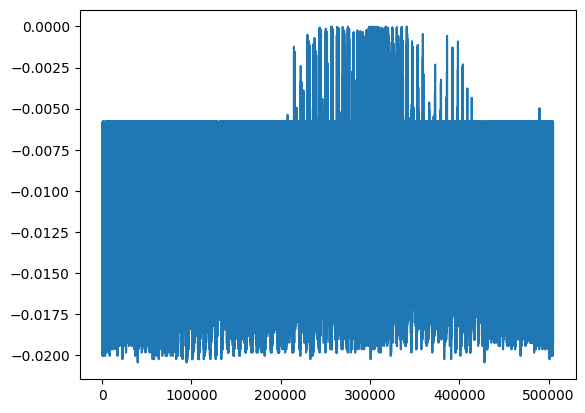

In [58]:
print(fdr_corrected_p)
print(raw_pval_vec[selected_vox_bool])
plt.plot(raw_pval_vec[selected_vox_bool]-fdr_corrected_p)

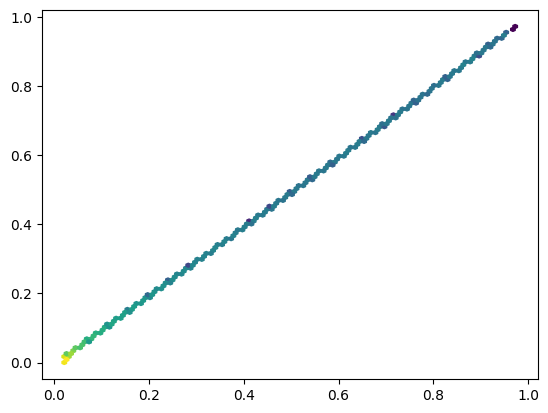

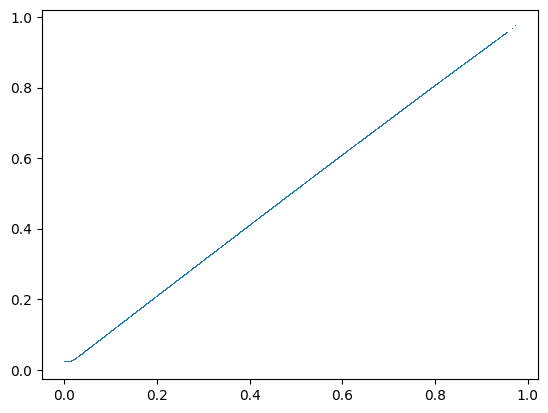

In [53]:
plt.hexbin(fdr_corrected_p, raw_pval_vec[selected_vox_bool],bins='log',mincnt=1)
plt.figure()
plt.plot(raw_pval_vec[selected_vox_bool],fdr_corrected_p,',')

(array([290888., 152145.,  21049.,   8968.,   4904.,   3534.,   2721.,
          2053.,   1601.,   1320.]),
 array([0.0004 , 0.02556, 0.05072, 0.07588, 0.10104, 0.1262 , 0.15136,
        0.17652, 0.20168, 0.22684, 0.252  ]),
 <BarContainer object of 10 artists>)

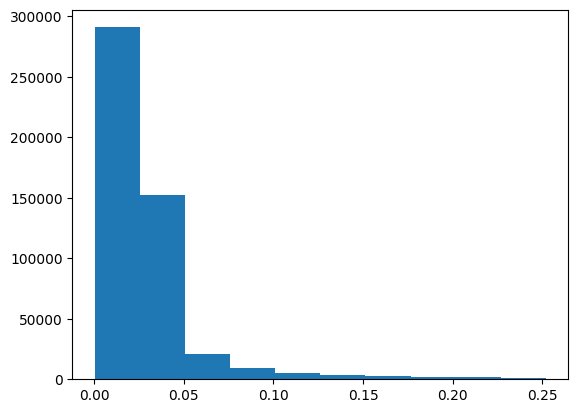

In [140]:
plt.hist(raw_pval_vec[selected_vox_bool][sig])

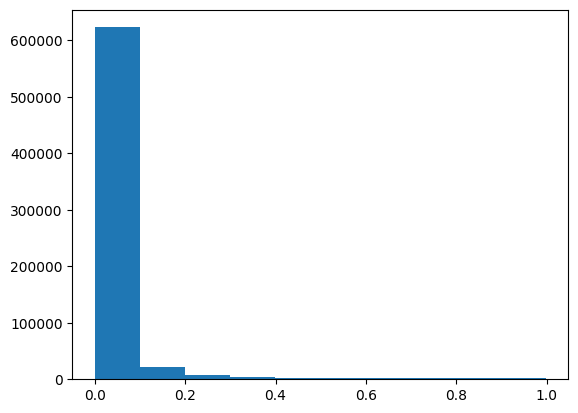

In [59]:
_=plt.hist(nb.load(raw_pvals_5k).get_fdata()[mask_d])

In [72]:
fdr_corrected_p

(array([False, False, False, ..., False, False, False], shape=(505011,)),
 array([0.08500179, 0.08500179, 0.08500179, ..., 0.08500179, 0.08500179,
        0.08500179], shape=(505011,)))

In [46]:
raw_pval_d = nb.load(raw_pvals_5k).get_fdata()[out_d.astype(bool)]
raw_pval_d.shape

(505011,)

(0.0, 0.2)

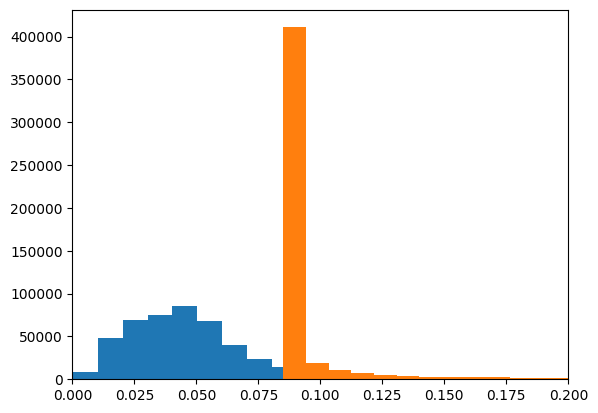

In [38]:
# _=plt.hist(direct[:,2],bins=100)
_ = plt.hist(indirect[:,2],bins=100)
_ = plt.hist(false_discovery_control(indirect[:,2]),bins=100)
plt.xlim(0,.2)

In [34]:
fdrcorrection(indirect[:,2][indirect[:,2]<0.01])

(array([ True,  True,  True, ...,  True,  True,  True], shape=(7641,)),
 array([0.0096, 0.0096, 0.0096, ..., 0.0096, 0.0096, 0.0096], shape=(7641,)))

0


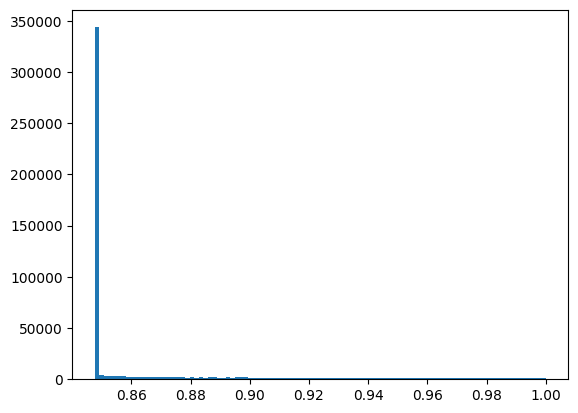

In [ ]:
_ = plt.hist((direct[:,2]),bins=100)
print((false_discovery_control(direct[:,2])<0.5).sum())

In [25]:
_fm = '../local_extras/mediation_FM-UL_Score_by_APM_Task_Score_pctThresh_0p01_minSs_19_indirect_zscored_nboot_5_coef.nii.gz'
_vgr = '../local_extras/mediation_VGR_Task_Score_by_APM_Task_Score_pctThresh_0p01_minSs_19_indirect_zscored_nboot_5_coef.nii.gz'
fm_vec = nb.load(_fm).get_fdata()[mask_d]
vgr_vec = nb.load(_vgr).get_fdata()[mask_d]


np.int64(0)

[[1.         0.97838855]
 [0.97838855 1.        ]]


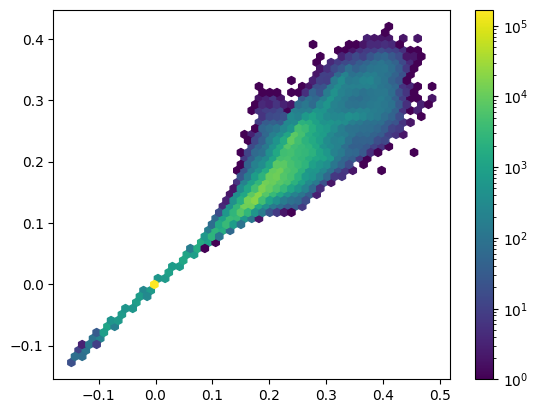

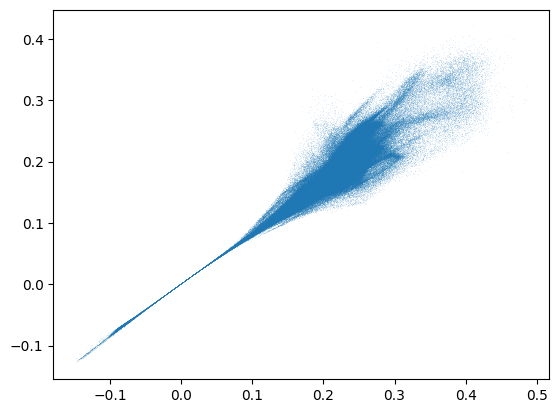

In [26]:
print(np.corrcoef(fm_vec*-1,vgr_vec))
plt.hexbin(fm_vec*-1,vgr_vec,gridsize=50,mincnt=1,bins='log'), plt.colorbar()
plt.figure()
plt.plot(fm_vec*-1,vgr_vec,',',alpha=0.1)

In [ ]:
%timeit mediation_analysis(data=_df, x='vox_dconn_z', m='APM Task Score', y='VGR Task Score',covar=['Age (y)', 'Sex (M=0)'], seed=42).to_numpy()

112 ms ± 6.22 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [293]:
%timeit run_single_voxel(0,n_boot=10)

11.3 ms ± 101 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
st = time.time()
_r = run_single_voxel(0,n_boot=5)
print(time.time()-st)
st = time.time()
_r2 = run_single_voxel(0,n_boot=5000)
print(time.time()-st)



0.017385005950927734
1.1070659160614014


(array([0.45423442, 0.14397542, 0.00335115, 0.16164117, 0.7468277 ,
        1.        ], dtype=float32),
 array([0.49647132, 0.16119266, 0.00408123, 0.16888842, 0.8240542 ,
        1.        ], dtype=float32),
 array([ 0.20405684,  0.17045216,  0.23952845, -0.14234364,  0.55045736,
         0.        ], dtype=float32),
 array([-0.02773931,  0.17750524,  0.8767698 , -0.38887644,  0.3333978 ,
         0.        ], dtype=float32),
 array([0.23179616, 0.19184901, 0.        , 0.26243585, 0.26243585,
        1.        ], dtype=float32))

In [ ]:
res2 = run_single_voxel(0)
vox_idx = 0
_df['vox_dconn_z'] = all_data[:,vox_idx]
res = mediation_analysis(data=_df, x='vox_dconn_z', m='APM Task Score', y='VGR Task Score',covar=['Age (y)', 'Sex (M=0)'], seed=42).to_numpy()


In [ ]:
for idx,rr in enumerate(res):
    print(f'{rr[2]} {res2[idx][1]}')


0.17166532520794564 0.17166532576084137
0.1447226506999749 0.14472265541553497
0.1824685483196152 0.18246854841709137
0.19001883767958302 0.19001883268356323
0.17033459063854972 0.170334592461586
